In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__results__.html
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__notebook__.ipynb
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__output__.json
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/custom.css
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/splits/train_test.pkl
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/models/label_encoder.pkl
/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/__results__.html
/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/__notebook__.ipynb
/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/__output__.json
/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/custom.css
/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/outputs/results/lgb56_confusion_matrix.png
/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/outputs/results/lgb_classification_report.csv
/kaggle/

In [2]:
import joblib
import numpy as np
import pandas as pd

X_train, X_test, y_train, y_test = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/splits/train_test.pkl"
)

print(X_train.shape)
print(X_test.shape)

(5055991, 77)
(1263998, 77)


In [3]:
feature_names = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/3-feature-selection/outputs/features/feature_names.pkl"
)

print(len(feature_names))

77


In [4]:
X_train_df = pd.DataFrame(
    X_train,
    columns=feature_names
)

X_test_df = pd.DataFrame(
    X_test,
    columns=feature_names
)

In [5]:
correlation_reduced_features = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/outputs/feature_selection/correlation/correlation_reduced_features.pkl"
)

print("Selected features:", len(correlation_reduced_features))

Selected features: 56


In [6]:
X_train_corr = X_train_df[
    correlation_reduced_features
]

X_test_corr = X_test_df[
    correlation_reduced_features
]

print("Train:", X_train_corr.shape)
print("Test :", X_test_corr.shape)

Train: (5055991, 56)
Test : (1263998, 56)


In [7]:
from sklearn.ensemble import RandomForestClassifier
import time

rf_56 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
    max_features="sqrt"
)

start = time.time()

rf_56.fit(
    X_train_corr,
    y_train
)

rf_time = (time.time() - start) / 60

print(f"RF training time: {rf_time:.2f} minutes")

RF training time: 48.06 minutes


In [8]:
y_pred_rf_56 = rf_56.predict(X_test_corr)
y_prob_rf_56 = rf_56.predict_proba(X_test_corr)

In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

rf_accuracy_56 = accuracy_score(y_test, y_pred_rf_56)

rf_precision_56 = precision_score(
    y_test,
    y_pred_rf_56,
    average="weighted",
    zero_division=0
)

rf_recall_56 = recall_score(
    y_test,
    y_pred_rf_56,
    average="weighted",
    zero_division=0
)

rf_f1_56 = f1_score(
    y_test,
    y_pred_rf_56,
    average="weighted",
    zero_division=0
)

rf_mcc_56 = matthews_corrcoef(
    y_test,
    y_pred_rf_56
)

rf_auc_56 = roc_auc_score(
    y_test,
    y_prob_rf_56,
    multi_class="ovr",
    average="weighted"
)

print(f"Accuracy : {rf_accuracy_56:.4f}")
print(f"Precision: {rf_precision_56:.4f}")
print(f"Recall   : {rf_recall_56:.4f}")
print(f"F1-score : {rf_f1_56:.4f}")
print(f"MCC      : {rf_mcc_56:.4f}")
print(f"AUC      : {rf_auc_56:.4f}")

Accuracy : 0.9688
Precision: 0.9664
Recall   : 0.9688
F1-score : 0.9676
MCC      : 0.9140
AUC      : 0.9819


In [10]:
from sklearn.metrics import classification_report

attack_names = [
    "Benign",
    "Bot",
    "Brute Force -Web",
    "Brute Force -XSS",
    "DDOS attack-HOIC",
    "DDoS attack-LOIC-UDP",
    "DDoS attacks-LOIC-HTTP",
    "DoS attacks-GoldenEye",
    "DoS attacks-Hulk",
    "DoS attacks-SlowHTTPTest",
    "DoS attacks-Slowloris",
    "FTP-BruteForce",
    "Infiltration",
    "SQL Injection",
    "SSH-Bruteforce"
]

print(classification_report(
    y_test,
    y_pred_rf_56,
    labels=range(15),
    target_names=attack_names,
    zero_division=0
))

                          precision    recall  f1-score   support

                  Benign       0.98      0.98      0.98    998829
                     Bot       1.00      1.00      1.00     28907
        Brute Force -Web       0.88      0.59      0.71       111
        Brute Force -XSS       0.89      0.69      0.78        45
        DDOS attack-HOIC       1.00      1.00      1.00     39772
    DDoS attack-LOIC-UDP       0.87      0.87      0.87       346
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00    115073
   DoS attacks-GoldenEye       1.00      1.00      1.00      8281
        DoS attacks-Hulk       1.00      1.00      1.00     29040
DoS attacks-SlowHTTPTest       0.00      0.00      0.00        11
   DoS attacks-Slowloris       0.98      0.99      0.99      1982
          FTP-BruteForce       0.08      0.10      0.09        10
            Infiltration       0.08      0.07      0.08     22764
           SQL Injection       0.83      0.59      0.69        17
         

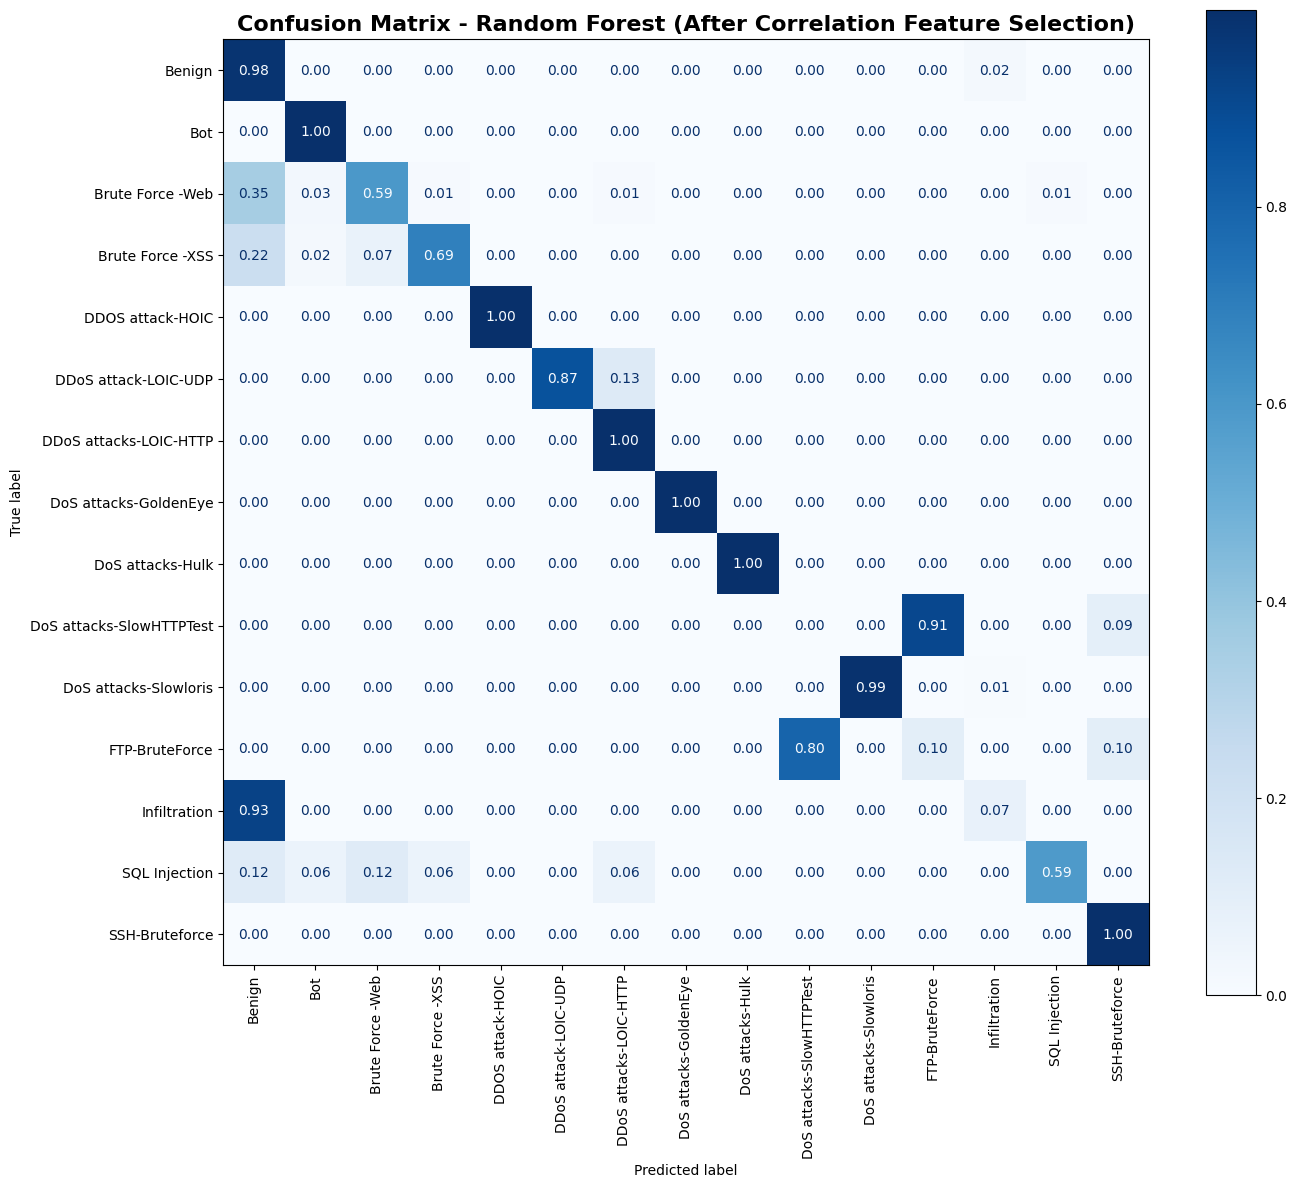

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(14,12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf_56,
    labels=range(15),
    display_labels=attack_names,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=90,
    ax=ax
)

plt.title(
    "Confusion Matrix - Random Forest (After Correlation Feature Selection)",
    fontsize=16,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

In [12]:
import os

os.makedirs("outputs/models", exist_ok=True)
os.makedirs("outputs/results", exist_ok=True)

In [13]:
import joblib

joblib.dump(
    rf_56,
    "outputs/models/rf_56.pkl"
)

print("rf_56 model saved!")

rf_56 model saved!


In [14]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [rf_accuracy_56],
    "Precision": [rf_precision_56],
    "Recall": [rf_recall_56],
    "F1": [rf_f1_56],
    "MCC": [rf_mcc_56],
    "AUC": [rf_auc_56]
})

metrics_df.to_csv(
    "outputs/results/rf_metrics.csv",
    index=False
)

print(metrics_df)

           Model  Accuracy  Precision    Recall        F1       MCC       AUC
0  Random Forest  0.968819   0.966403  0.968819  0.967596  0.914026  0.981896


In [15]:
attack_names = [
    "Benign",
    "Bot",
    "Brute Force -Web",
    "Brute Force -XSS",
    "DDOS attack-HOIC",
    "DDoS attack-LOIC-UDP",
    "DDoS attacks-LOIC-HTTP",
    "DoS attacks-GoldenEye",
    "DoS attacks-Hulk",
    "DoS attacks-SlowHTTPTest",
    "DoS attacks-Slowloris",
    "FTP-BruteForce",
    "Infiltration",
    "SQL Injection",
    "SSH-Bruteforce"
]
report = classification_report(
    y_test,
    y_pred_rf_56,
    labels=range(15),
    target_names=attack_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "outputs/results/rf_classification_report.csv"
)

print("Classification Report Saved!")

Classification Report Saved!


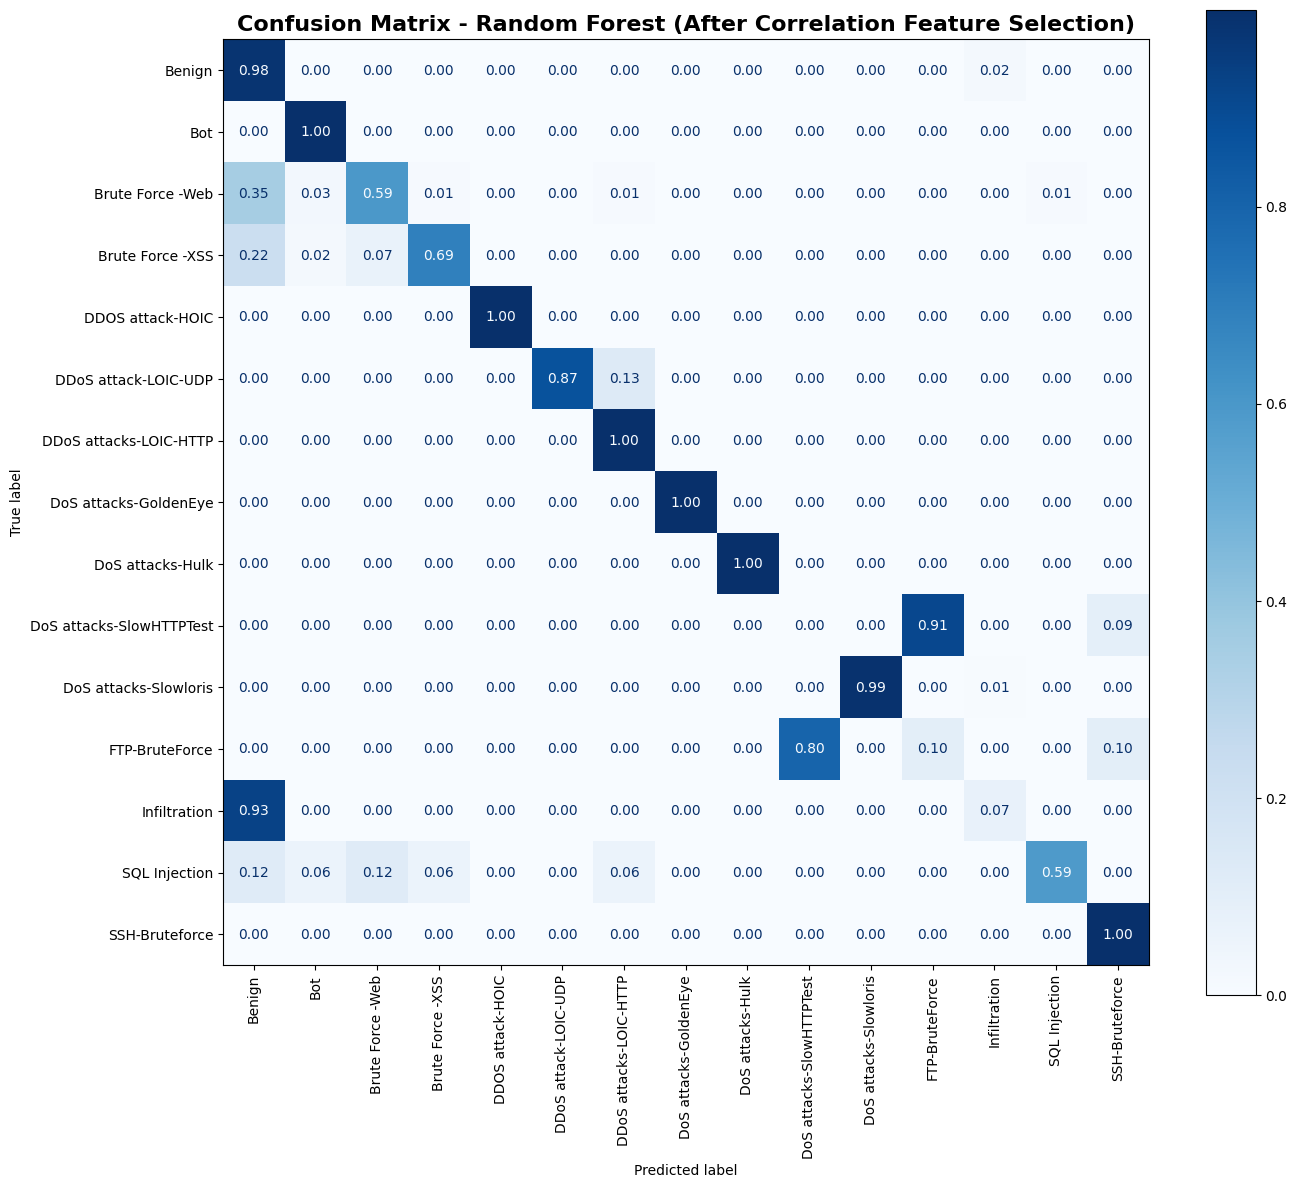

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(14,12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf_56,
    labels=range(15),
    display_labels=attack_names,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=90,
    ax=ax
)
plt.title(
    "Confusion Matrix - Random Forest (After Correlation Feature Selection)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "outputs/results/rf56_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()